# 04 — Caracterização das Reclamações Não Avaliadas

Este notebook caracteriza as reclamações classificadas como **Não Avaliada** e compara sua composição com a população supervisionada, com atenção especial ao período **out-of-time (OOT)**.

As reclamações `Não Avaliada` não possuem variável-alvo conhecida. Portanto, não são utilizadas para treinamento, cálculo de métricas, escolha de algoritmo, ajuste de hiperparâmetros ou definição de threshold. A finalidade desta etapa é exclusivamente **descritiva e exploratória**.


## 1. Bibliotecas e configurações


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Diretórios e arquivos


In [2]:
PROJECT_DIR = Path(r"C:\UnB\script_md")
PROCESSADOS_DIR = PROJECT_DIR / "Base de dados" / "processados"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figuras"
TABLES_DIR = PROJECT_DIR / "outputs" / "tabelas"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

FILE_SUPERVISIONADA = PROCESSADOS_DIR / "dataset_modelagem_preparado.csv"
FILE_NAO_AVALIADAS = PROCESSADOS_DIR / "dataset_nao_avaliadas_aplicacao.csv"

if not FILE_SUPERVISIONADA.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {FILE_SUPERVISIONADA}. "
        "Execute primeiro o notebook 03_preparacao_dados.ipynb."
    )

if not FILE_NAO_AVALIADAS.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {FILE_NAO_AVALIADAS}. "
        "Execute primeiro o notebook 03_preparacao_dados.ipynb."
    )

print(f"Supervisionada: {FILE_SUPERVISIONADA}")
print(f"Não avaliadas: {FILE_NAO_AVALIADAS}")


Supervisionada: C:\UnB\script_md\Base de dados\processados\dataset_modelagem_preparado.csv
Não avaliadas: C:\UnB\script_md\Base de dados\processados\dataset_nao_avaliadas_aplicacao.csv


## 3. Carregamento das bases


In [3]:
df_sup = pd.read_csv(
    FILE_SUPERVISIONADA,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

df_na = pd.read_csv(
    FILE_NAO_AVALIADAS,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

print(f"Base supervisionada: {len(df_sup):,} registros")
print(f"Base não avaliada:   {len(df_na):,} registros")


Base supervisionada: 58,131 registros
Base não avaliada:   151,739 registros


## 4. Preditores e partições temporais

A comparação usa exatamente os mesmos 11 preditores definidos no notebook 03. A base não avaliada recebe as mesmas três partições temporais: Treino, Teste e OOT.


In [4]:
PREDITORES = [
    "Região",
    "UF",
    "Cidade",
    "Sexo",
    "Faixa Etária",
    "Área",
    "Assunto",
    "Grupo Problema",
    "Problema",
    "Como Comprou Contratou",
    "Procurou Empresa"
]

for coluna in PREDITORES + ["AAAA_MM"]:
    if coluna not in df_sup.columns:
        raise KeyError(f"Coluna ausente na base supervisionada: {coluna}")
    if coluna not in df_na.columns:
        raise KeyError(f"Coluna ausente na base não avaliada: {coluna}")

periodos = sorted(df_sup["AAAA_MM"].dropna().unique())

if len(periodos) != 48:
    raise ValueError(
        f"Foram encontrados {len(periodos)} meses na base supervisionada; eram esperados 48."
    )

periodos_treino = periodos[:24]
periodos_teste = periodos[24:36]
periodos_oot = periodos[36:48]

def classificar_periodo(periodo):
    if periodo in periodos_treino:
        return "Treino"
    if periodo in periodos_teste:
        return "Teste"
    if periodo in periodos_oot:
        return "OOT"
    return "Fora do recorte"

df_sup["Particao_temporal"] = df_sup["AAAA_MM"].map(classificar_periodo)
df_na["Particao_temporal"] = df_na["AAAA_MM"].map(classificar_periodo)

print(f"Treino: {periodos_treino[0]} a {periodos_treino[-1]}")
print(f"Teste:  {periodos_teste[0]} a {periodos_teste[-1]}")
print(f"OOT:    {periodos_oot[0]} a {periodos_oot[-1]}")


Treino: 2022_08 a 2024_07
Teste:  2024_08 a 2025_07
OOT:    2025_08 a 2026_07


## 5. Composição geral: avaliadas versus não avaliadas


In [5]:
resumo_populacoes = pd.concat([
    df_sup.groupby("Particao_temporal").size().rename("Avaliadas"),
    df_na.groupby("Particao_temporal").size().rename("Não Avaliadas")
], axis=1).fillna(0).astype(int)

resumo_populacoes = resumo_populacoes.reindex(
    ["Treino", "Teste", "OOT"]
)

resumo_populacoes["Total"] = (
    resumo_populacoes["Avaliadas"] +
    resumo_populacoes["Não Avaliadas"]
)

resumo_populacoes["Avaliadas (%)"] = (
    resumo_populacoes["Avaliadas"]
    .div(resumo_populacoes["Total"])
    .mul(100)
    .round(2)
)

resumo_populacoes["Não Avaliadas (%)"] = (
    resumo_populacoes["Não Avaliadas"]
    .div(resumo_populacoes["Total"])
    .mul(100)
    .round(2)
)

display(resumo_populacoes)

resumo_populacoes.to_csv(
    TABLES_DIR / "nao_avaliadas_resumo_populacoes_particao.csv",
    sep=";",
    encoding="utf-8-sig"
)


,Avaliadas,Não Avaliadas,Total,Avaliadas (%),Não Avaliadas (%)
Particao_temporal,,,,,
Treino,12032,18320,30352,39.64,60.36
Teste,14027,38893,52920,26.51,73.49
OOT,32072,94526,126598,25.33,74.67


### 5.1 Participação das reclamações não avaliadas por partição


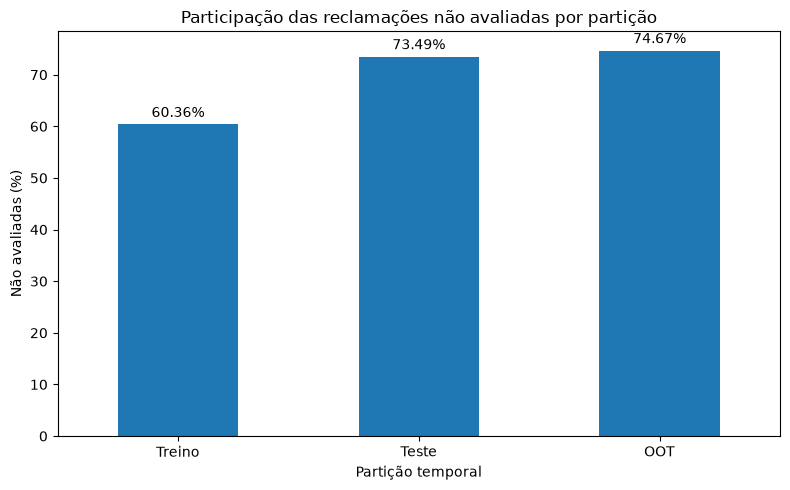

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

resumo_populacoes["Não Avaliadas (%)"].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Participação das reclamações não avaliadas por partição")
ax.set_xlabel("Partição temporal")
ax.set_ylabel("Não avaliadas (%)")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "nao_avaliadas_percentual_por_particao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 6. Evolução mensal das populações


In [7]:
volume_sup_mes = (
    df_sup.groupby("AAAA_MM")
    .size()
    .rename("Avaliadas")
)

volume_na_mes = (
    df_na.groupby("AAAA_MM")
    .size()
    .rename("Não Avaliadas")
)

volume_mensal = pd.concat(
    [volume_sup_mes, volume_na_mes],
    axis=1
).fillna(0).astype(int)

volume_mensal["Total"] = (
    volume_mensal["Avaliadas"] +
    volume_mensal["Não Avaliadas"]
)

volume_mensal["Não Avaliadas (%)"] = (
    volume_mensal["Não Avaliadas"]
    .div(volume_mensal["Total"])
    .mul(100)
    .round(2)
)

display(volume_mensal)

volume_mensal.to_csv(
    TABLES_DIR / "nao_avaliadas_evolucao_mensal.csv",
    sep=";",
    encoding="utf-8-sig"
)


,Avaliadas,Não Avaliadas,Total,Não Avaliadas (%)
AAAA_MM,,,,
2022_08,353,417,770,54.16
2022_09,398,403,801,50.31
2022_10,323,397,720,55.14
2022_11,397,419,816,51.35
2022_12,390,780,1170,66.67
2023_01,360,438,798,54.89
2023_02,297,307,604,50.83
2023_03,654,858,1512,56.75
2023_04,454,842,1296,64.97


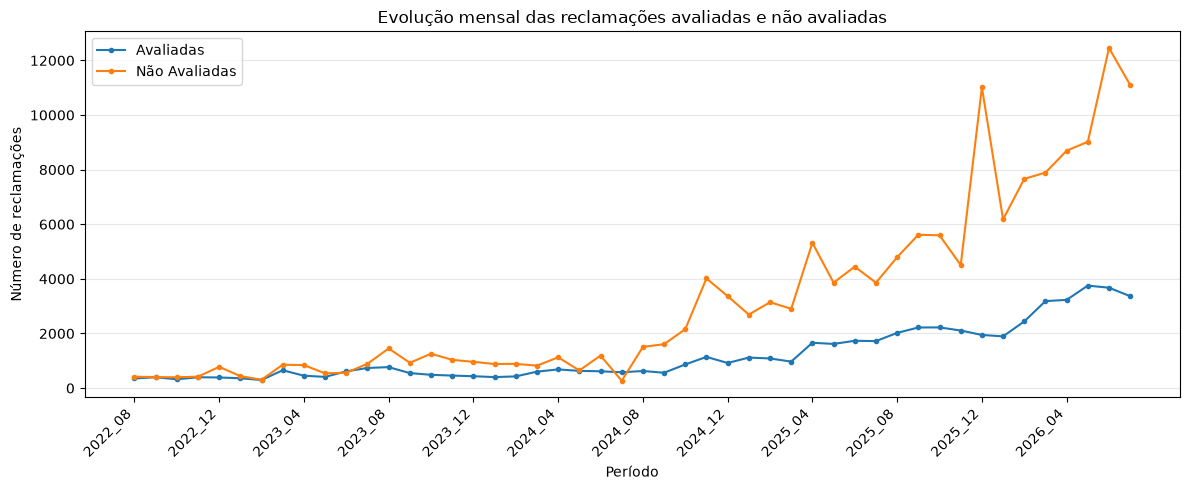

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    volume_mensal.index,
    volume_mensal["Avaliadas"],
    marker="o",
    markersize=3,
    label="Avaliadas"
)

ax.plot(
    volume_mensal.index,
    volume_mensal["Não Avaliadas"],
    marker="o",
    markersize=3,
    label="Não Avaliadas"
)

ax.set_title("Evolução mensal das reclamações avaliadas e não avaliadas")
ax.set_xlabel("Período")
ax.set_ylabel("Número de reclamações")

passo_rotulo = 4
posicoes = list(range(0, len(volume_mensal), passo_rotulo))

ax.set_xticks(posicoes)
ax.set_xticklabels(
    volume_mensal.index[posicoes],
    rotation=45,
    ha="right"
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "nao_avaliadas_evolucao_mensal_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 6.1 Evolução mensal do percentual de não avaliadas


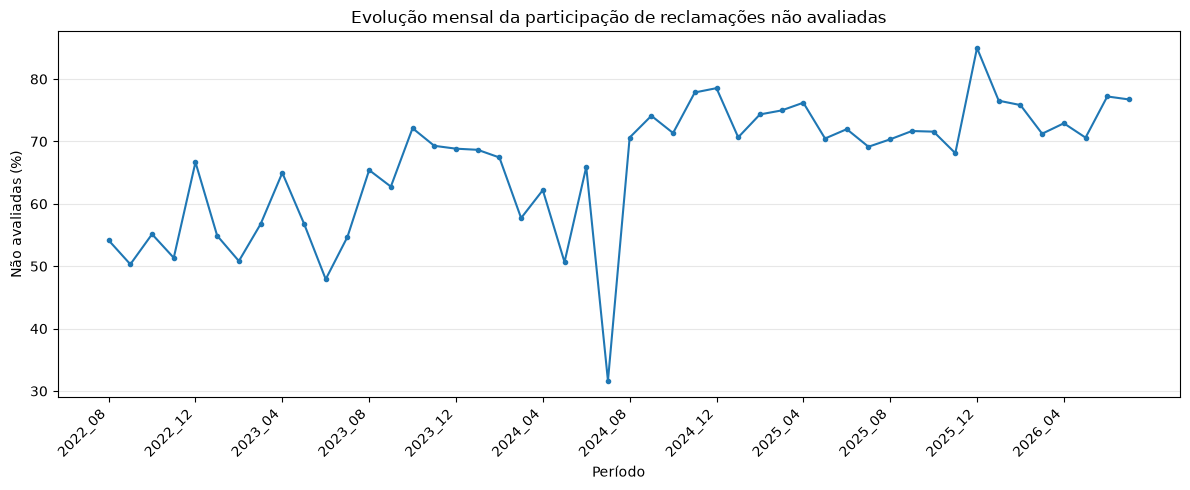

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    volume_mensal.index,
    volume_mensal["Não Avaliadas (%)"],
    marker="o",
    markersize=3
)

ax.set_title("Evolução mensal da participação de reclamações não avaliadas")
ax.set_xlabel("Período")
ax.set_ylabel("Não avaliadas (%)")

ax.set_xticks(posicoes)
ax.set_xticklabels(
    volume_mensal.index[posicoes],
    rotation=45,
    ha="right"
)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "nao_avaliadas_evolucao_mensal_percentual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 7. Cobertura categórica ao longo do tempo

A tabela abaixo usa o **treino supervisionado** como referência e verifica quantas categorias novas surgem nas populações de teste e OOT, tanto avaliadas quanto não avaliadas.


In [10]:
df_sup_treino = df_sup[
    df_sup["Particao_temporal"] == "Treino"
].copy()

df_sup_teste = df_sup[
    df_sup["Particao_temporal"] == "Teste"
].copy()

df_sup_oot = df_sup[
    df_sup["Particao_temporal"] == "OOT"
].copy()

df_na_teste = df_na[
    df_na["Particao_temporal"] == "Teste"
].copy()

df_na_oot = df_na[
    df_na["Particao_temporal"] == "OOT"
].copy()

linhas_cobertura = []

for coluna in PREDITORES:
    categorias_treino = set(df_sup_treino[coluna].dropna().astype(str).unique())
    categorias_sup_teste = set(df_sup_teste[coluna].dropna().astype(str).unique())
    categorias_sup_oot = set(df_sup_oot[coluna].dropna().astype(str).unique())
    categorias_na_teste = set(df_na_teste[coluna].dropna().astype(str).unique())
    categorias_na_oot = set(df_na_oot[coluna].dropna().astype(str).unique())

    linhas_cobertura.append({
        "Variável": coluna,
        "Categorias treino": len(categorias_treino),
        "Novas teste avaliado": len(categorias_sup_teste - categorias_treino),
        "Novas OOT avaliado": len(categorias_sup_oot - categorias_treino),
        "Novas teste não avaliado": len(categorias_na_teste - categorias_treino),
        "Novas OOT não avaliado": len(categorias_na_oot - categorias_treino),
    })

cobertura_categorias = pd.DataFrame(linhas_cobertura).sort_values(
    by="Novas OOT não avaliado",
    ascending=False
)

display(cobertura_categorias)

cobertura_categorias.to_csv(
    TABLES_DIR / "nao_avaliadas_cobertura_categorias.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Variável,Categorias treino,Novas teste avaliado,Novas OOT avaliado,Novas teste não avaliado,Novas OOT não avaliado
2,Cidade,1774,874,1531,1922,2895
8,Problema,85,2,5,4,5
6,Assunto,27,1,0,1,1
1,UF,27,0,0,0,0
0,Região,5,0,0,0,0
4,Faixa Etária,7,0,0,0,0
3,Sexo,3,0,0,0,0
5,Área,3,0,0,0,0
7,Grupo Problema,8,0,0,0,0
9,Como Comprou Contratou,9,0,0,0,0


## 8. Distância entre distribuições categóricas

Para resumir diferenças entre as populações, será utilizada a **distância de variação total** (*Total Variation Distance — TVD*).

A medida varia entre 0 e 1:

- `0`: distribuições idênticas;
- `1`: distribuições sem sobreposição.

Neste notebook, a TVD é utilizada apenas de forma descritiva. Não será utilizada para escolha de modelo ou definição de limiares de estabilidade.


In [11]:
def total_variation_distance(serie_a, serie_b):
    dist_a = serie_a.astype(str).value_counts(normalize=True)
    dist_b = serie_b.astype(str).value_counts(normalize=True)

    categorias = dist_a.index.union(dist_b.index)

    p = dist_a.reindex(categorias, fill_value=0)
    q = dist_b.reindex(categorias, fill_value=0)

    return 0.5 * np.abs(p - q).sum()


### 8.1 Avaliadas versus não avaliadas dentro do OOT


In [12]:
linhas_tvd = []

for coluna in PREDITORES:
    tvd = total_variation_distance(
        df_sup_oot[coluna],
        df_na_oot[coluna]
    )

    linhas_tvd.append({
        "Variável": coluna,
        "TVD - OOT avaliado vs não avaliado": round(float(tvd), 4)
    })

tvd_oot = pd.DataFrame(linhas_tvd).sort_values(
    "TVD - OOT avaliado vs não avaliado",
    ascending=False
)

display(tvd_oot)

tvd_oot.to_csv(
    TABLES_DIR / "nao_avaliadas_tvd_oot.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Variável,TVD - OOT avaliado vs não avaliado
2,Cidade,0.16
8,Problema,0.10
4,Faixa Etária,0.07
10,Procurou Empresa,0.05
7,Grupo Problema,0.04
1,UF,0.04
9,Como Comprou Contratou,0.03
0,Região,0.03
6,Assunto,0.02
3,Sexo,0.01


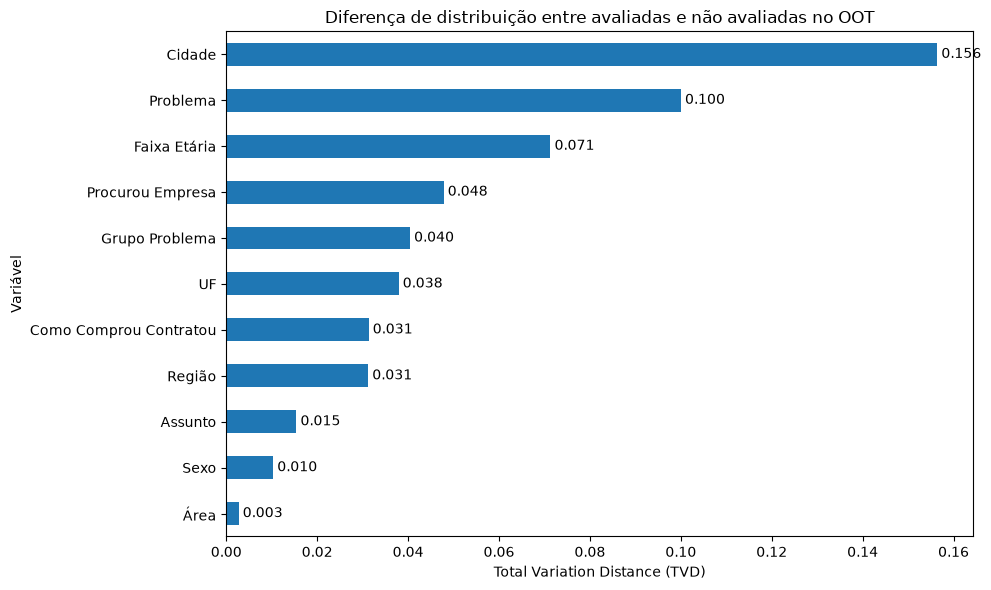

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

dados_plot = (
    tvd_oot
    .set_index("Variável")["TVD - OOT avaliado vs não avaliado"]
    .sort_values()
)

dados_plot.plot(
    kind="barh",
    ax=ax
)

ax.set_title("Diferença de distribuição entre avaliadas e não avaliadas no OOT")
ax.set_xlabel("Total Variation Distance (TVD)")
ax.set_ylabel("Variável")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "nao_avaliadas_tvd_oot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 9. Detalhamento das variáveis com maior diferença no OOT

São apresentadas as dez categorias com maior diferença absoluta, em pontos percentuais, para as três variáveis com maior TVD.


In [14]:
top_variaveis = tvd_oot.head(3)["Variável"].tolist()

def comparar_distribuicoes_top(data_a, data_b, coluna, top_n=10):
    freq_a = (
        data_a[coluna]
        .astype(str)
        .value_counts(normalize=True)
        .mul(100)
        .rename("Avaliadas (%)")
    )

    freq_b = (
        data_b[coluna]
        .astype(str)
        .value_counts(normalize=True)
        .mul(100)
        .rename("Não Avaliadas (%)")
    )

    tabela = pd.concat(
        [freq_a, freq_b],
        axis=1
    ).fillna(0)

    tabela["Diferença absoluta (p.p.)"] = (
        tabela["Não Avaliadas (%)"] -
        tabela["Avaliadas (%)"]
    ).abs()

    return (
        tabela.sort_values(
            "Diferença absoluta (p.p.)",
            ascending=False
        )
        .head(top_n)
        .round(2)
    )

for coluna in top_variaveis:
    print(f"\nVariável: {coluna}")
    display(
        comparar_distribuicoes_top(
            df_sup_oot,
            df_na_oot,
            coluna,
            top_n=10
        )
    )



Variável: Cidade


,Avaliadas (%),Não Avaliadas (%),Diferença absoluta (p.p.)
Cidade,,,
São Paulo,7.14,6.34,0.79
Brasília,3.65,3.08,0.57
Salvador,2.43,1.95,0.48
Rio de Janeiro,3.14,2.76,0.38
Curitiba,1.70,1.35,0.35
Boa Vista,0.63,0.98,0.35
São Luís,1.04,1.26,0.22
Belo Horizonte,1.82,1.60,0.22
Natal,0.95,0.80,0.15



Variável: Problema


,Avaliadas (%),Não Avaliadas (%),Diferença absoluta (p.p.)
Problema,,,
Renegociação / parcelamento de dívida,22.49,16.87,5.62
Não entrega do contrato ou documentação relacionada ao serviço,2.15,4.47,2.32
SAC - Demanda não resolvida / não respondida / respondida após o prazo,3.60,4.94,1.34
Negativação indevida referente à pagamento já efetuado,4.87,6.09,1.22
Dificuldade para rescindir o contrato / cancelar o serviço,0.51,1.46,0.95
"Cálculo de juros, saldo devedor (contestação, solicitação de histórico, dúvidas)",20.18,21.07,0.90
Dificuldade / atraso na devolução de valores pagos / reembolso / retenção de valores,1.99,1.42,0.56
Cobrança indevida / abusiva para alterar ou cancelar o contrato,8.73,9.25,0.51
Não envio / atraso do boleto ou fatura / dificuldade com o pagamento,0.58,0.96,0.38



Variável: Faixa Etária


,Avaliadas (%),Não Avaliadas (%),Diferença absoluta (p.p.)
Faixa Etária,,,
entre 21 a 30 anos,19.99,25.95,5.97
entre 41 a 50 anos,25.89,21.48,4.41
entre 51 a 60 anos,13.69,12.27,1.42
entre 31 a 40 anos,29.20,28.00,1.20
até 20 anos,1.58,2.51,0.93
mais de 70 anos,2.76,3.00,0.24
entre 61 a 70 anos,6.89,6.79,0.10


## 10. Síntese descritiva do período OOT


In [15]:
n_sup_oot = len(df_sup_oot)
n_na_oot = len(df_na_oot)
n_total_oot = n_sup_oot + n_na_oot

pct_na_oot = n_na_oot / n_total_oot * 100

variavel_maior_tvd = tvd_oot.iloc[0]["Variável"]
maior_tvd = tvd_oot.iloc[0]["TVD - OOT avaliado vs não avaliado"]

categorias_novas_oot_na = int(
    cobertura_categorias["Novas OOT não avaliado"].sum()
)

print(
    f"No período OOT, foram observadas {n_sup_oot:,} reclamações avaliadas "
    f"e {n_na_oot:,} reclamações não avaliadas. "
    f"As não avaliadas representaram {pct_na_oot:.2f}% das reclamações "
    f"consideradas nessa comparação."
)

print()

print(
    f"A variável com maior diferença distributiva entre avaliadas e não avaliadas "
    f"no OOT foi '{variavel_maior_tvd}', com TVD de {maior_tvd:.4f}."
)

print()

print(
    f"Considerando os 11 preditores, foram identificadas "
    f"{categorias_novas_oot_na:,} categorias novas no OOT não avaliado "
    f"em relação ao conjunto de treinamento supervisionado."
)


No período OOT, foram observadas 32,072 reclamações avaliadas e 94,526 reclamações não avaliadas. As não avaliadas representaram 74.67% das reclamações consideradas nessa comparação.

A variável com maior diferença distributiva entre avaliadas e não avaliadas no OOT foi 'Cidade', com TVD de 0.1564.

Considerando os 11 preditores, foram identificadas 2,901 categorias novas no OOT não avaliado em relação ao conjunto de treinamento supervisionado.


## 11. Quadro consolidado para apoio ao artigo


In [16]:
resumo_artigo = pd.DataFrame({
    "Indicador": [
        "Reclamações avaliadas no OOT",
        "Reclamações não avaliadas no OOT",
        "Não avaliadas no OOT (%)",
        "Variável com maior diferença distributiva no OOT",
        "Maior TVD no OOT",
        "Total de categorias novas no OOT não avaliado"
    ],
    "Resultado": [
        f"{n_sup_oot:,}",
        f"{n_na_oot:,}",
        f"{pct_na_oot:.2f}%",
        variavel_maior_tvd,
        f"{maior_tvd:.4f}",
        f"{categorias_novas_oot_na:,}"
    ]
})

display(resumo_artigo)

resumo_artigo.to_csv(
    TABLES_DIR / "nao_avaliadas_resumo_artigo.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)


,Indicador,Resultado
0,Reclamações avaliadas no OOT,"32,072"
1,Reclamações não avaliadas no OOT,"94,526"
2,Não avaliadas no OOT (%),74.67%
3,Variável com maior diferença distributiva no OOT,Cidade
4,Maior TVD no OOT,0.1564
5,Total de categorias novas no OOT não avaliado,"2,901"


## 12. Interpretação metodológica

A população `Não Avaliada` deve ser interpretada como **não rotulada**, e não como um conjunto de teste.

A comparação desta etapa permite verificar diferenças de composição, categorias novas e alterações distributivas, mas a validade preditiva dos classificadores continuará sendo medida exclusivamente sobre observações com desfecho conhecido.


## 13. Próxima etapa

Com a população não avaliada caracterizada, o próximo notebook iniciará a modelagem supervisionada:

1. separação de `X_train`, `X_test` e `X_oot`;
2. codificação categórica ajustada apenas no treino;
3. `DummyClassifier` como referência mínima;
4. Regressão Logística como baseline interpretável;
5. avaliação inicial no conjunto de teste;
6. preservação do OOT para a avaliação final de generalização temporal.
